In [1]:
import os


os.environ["RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO"] = "0"
os.environ["RAY_DEDUP_LOGS"] = "1"

In [2]:
# %%
import matplotlib.pyplot as plt
import numpy as np
import ray
import pandas as pd


from mpl_toolkits.mplot3d import Axes3D

from starforge.blackholes.parameters_recover.parameters_recovery import (
    ParametersRecoveryRemote
)

from starforge.blackholes.parameters_recover.metrics import (
    nrmse_percent,
    smape_percent,
    stabilized_mape_percent,
)

from starforge.blackholes.accretionrate.blackholesaccretionrate import (
    ParameterAccretionRate
)

from starforge.blackholes.parameters_recover.utils import (
    add_noise_to_data,
    gaussian_sum_from_p,
    make_bounds_for_gaussians,
)

from starforge.blackholes.parameters_recover.schemes import (
    GridParameters
)

In [3]:
if ray.is_initialized() is False:
    ray.init(ignore_reinit_error=True)

2026-05-19 16:25:40,017	INFO worker.py:2004 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 


In [4]:
# ============================================================
# GRID
# ============================================================

mbh_steps = 25

grid_params = GridParameters(
    mbh_steps=mbh_steps,
    z_steps=mbh_steps * 100
)

ln_mbh_grid = np.linspace(
    grid_params.mbh_i,
    grid_params.mbh_f,
    grid_params.mbh_steps
)

In [5]:
# %%
# ============================================================
# BENCHMARK INITIAL CONDITION
# ============================================================

benchmark_params = np.array([
    3.3e-02,
    8.2e-03,
    5.4e-02,
    1.07e+01,
    1.29e+01,
    1.21e+01,
    6.93e-01,
    1.05e+00,
    7.47e-01
])

initial_condition = gaussian_sum_from_p(
    benchmark_params,
    ln_mbh_grid,
    n_gauss=3
)

In [6]:
# %%
# ============================================================
# PHYSICAL MODEL PARAMETERS
# ============================================================

accretion_params = ParameterAccretionRate(
    mbh_par=2e11,
    alpha_par=3e-1,
    tau_par=5e9,
    eta=0.1,
    t_q=1e9,
    b_1=0.1,
    b_2=0.1,
)

In [7]:
# ============================================================
# FORWARD SOLVER
# ============================================================

objective_function = ParametersRecoveryRemote.remote(
    grid_params=grid_params
)

In [8]:
# %%
# ============================================================
# REFERENCE FINAL BHMF
# ============================================================

reference_outputs = ray.get(
    objective_function.directly_problem.remote(
        initial_condition,
        accretion_params
    )
)

reference_final = reference_outputs.n_final

In [9]:
# ============================================================
# SYNTHETIC OBSERVATION
# ============================================================

noise_level = 0.01

target_data = add_noise_to_data(
    data=reference_final,
    mu=0.0,
    sigma=noise_level,
    rho=0.5,
    alpha=0.5,
    seed=52,
    noise_type='mixed'
)

In [10]:
# %%
# ============================================================
# OPTIMIZATION BOUNDS
# ============================================================

bounds = make_bounds_for_gaussians(
    x_min=6.0,
    x_max=15.0,
    preferred_center_index=2,
    preferred_center=12.0,
    preferred_center_radius=1.0,
    Amax=1e-1,
    sigma_min=0.01,
    sigma_max=5.0,
    sigma_max_preferred=1.0,
    K=3
)

bounds.extend([
    (0.5, 5.0),     # mbh_par
    (1.0, 10.0),    # tau_par
    (0.01, 0.6),    # alpha_par
    (0.01, 0.5),    # eta
    (0.5, 5.0),     # t_q
    (0.01, 0.5),    # b_1
    (0.01, 0.5),    # b_2
])

In [11]:
# %%
recovery = ParametersRecoveryRemote.remote(
    grid_params=grid_params
)

In [12]:
return_components = True

In [13]:
# %%
# ============================================================
# L-SURFACE COMPUTATION
# ============================================================

alpha_p_values = np.logspace(-3, 0, 10)
alpha_theta_values = np.logspace(-3, 0, 10)

results = []

for alpha_p in alpha_p_values:
    for alpha_theta in alpha_theta_values:

        print(
            f"Running optimization with "
            f"alpha_p={alpha_p:.2e}, "
            f"alpha_theta={alpha_theta:.2e}"
        )

        # ----------------------------------------------------
        # Optimization
        # ----------------------------------------------------

        best = ray.get(
            recovery.optimizer.remote(
                bounds=bounds,
                target_data=target_data,
                weight_p=alpha_p,
                weight_theta=alpha_theta,
                n_max=1
            )
        )

        # ----------------------------------------------------
        # Diagnostics
        # ----------------------------------------------------

        diagnostics = ray.get(
            recovery.objective_function.remote(
                np.array(best.x),
                target_data,
                weight_p=alpha_p,
                weight_theta=alpha_theta,
                return_components=True
            )
        )

        results.append({
            "alpha_p": alpha_p,
            "alpha_theta": alpha_theta,
            "objective": diagnostics["objective"],
            "misfit": diagnostics["misfit"],
            "R_p": diagnostics["R_p"],
            "R_theta": diagnostics["R_theta"],
            "best_parameters": np.array(best.x),
        })

Running optimization with alpha_p=1.00e-03, alpha_theta=1.00e-03
(ParametersRecovery pid=601114) Starting optimization ...
(ParametersRecovery pid=601114) Objective value: 3.438873e-01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=601114) Objective value: 3.400214e-01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=601114) Objective value: 2.895432e-01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=601114) Objective value: 2.762353e-01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=601114) Objective value: 2.303250e-01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=601114) Objective value: 2.027036e-01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=601114) Objective value: 1.229655e-01 | Context: Minimum detected in annealing process


(ParametersRecovery pid=601114) /home/eduardo/Projects/starforge2/.venv/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
(ParametersRecovery pid=601114)   df = [f_eval - f0 for f_eval in f_evals]


(ParametersRecovery pid=601114) Objective value: 1.217332e-01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=601114) Objective value: 4.968043e-02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=601114) Objective value: 1.730237e-02 | Context: Detection occurred in local search
Running optimization with alpha_p=1.00e-03, alpha_theta=2.15e-03
(ParametersRecovery pid=601114) Stage 1/1 | Best Objective: 1.730237e-02
(ParametersRecovery pid=601114) Optimization completed | Final Objective: 1.730237e-02
(ParametersRecovery pid=601114) Starting optimization ...
(ParametersRecovery pid=601114) Objective value: 2.439127e-01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=601114) Objective value: 2.218888e-01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=601114) Objective value: 1.784689e-01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=601114) Objective value: 1.369

(ParametersRecovery pid=601114) /home/eduardo/Projects/starforge2/src/starforge/blackholes/parameters_recover/parameters_recovery.py:202: RuntimeWarning: invalid value encountered in log10
(ParametersRecovery pid=601114)   normalization_model = np.log10(params_array[-n:] + epsilon)


Running optimization with alpha_p=1.00e-03, alpha_theta=2.15e-02
(ParametersRecovery pid=601114) Stage 1/1 | Best Objective: 9.035593e-02
(ParametersRecovery pid=601114) Optimization completed | Final Objective: 9.035593e-02
(ParametersRecovery pid=601114) Starting optimization ...
(ParametersRecovery pid=601114) Objective value: 2.309184e-01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=601114) Objective value: 2.215292e-01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=601114) Objective value: 1.995269e-01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=601114) Objective value: 1.902941e-01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=601114) Objective value: 1.874699e-01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=601114) Objective value: 1.724001e-01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=601114) Objective value: 1.

(ParametersRecovery pid=601114) /home/eduardo/Projects/starforge2/src/starforge/blackholes/discreteblackholemf/blackholesmassfunction.py:86: RuntimeWarning: invalid value encountered in log10
(ParametersRecovery pid=601114)   x = log10_m_grid - np.log10(self.accretionrate.params.mbh_par)


(ParametersRecovery pid=601114) Objective value: 1.272999e+00 | Context: Minimum detected in annealing process
(ParametersRecovery pid=601114) Objective value: 1.217854e+00 | Context: Minimum detected in annealing process
(ParametersRecovery pid=601114) Objective value: 1.130123e+00 | Context: Minimum detected in annealing process
(ParametersRecovery pid=601114) Objective value: 1.104706e+00 | Context: Minimum detected in annealing process
(ParametersRecovery pid=601114) Objective value: 1.097122e+00 | Context: Minimum detected in annealing process
(ParametersRecovery pid=601114) Objective value: 1.094814e+00 | Context: Minimum detected in annealing process
(ParametersRecovery pid=601114) Objective value: 1.088826e+00 | Context: Minimum detected in annealing process
Running optimization with alpha_p=1.00e-03, alpha_theta=4.64e-01
(ParametersRecovery pid=601114) Stage 1/1 | Best Objective: 1.088826e+00
(ParametersRecovery pid=601114) Optimization completed | Final Objective: 1.088826e+0

(ParametersRecovery pid=601114) /home/eduardo/Projects/starforge2/src/starforge/blackholes/discreteblackholemf/blackholesmassfunction.py:56: RuntimeWarning: overflow encountered in exp
(ParametersRecovery pid=601114)   u = np.exp((alpha - 1) * x) * (tau_star / age) * \


(ParametersRecovery pid=601114) Objective value: 6.667991e-01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=601114) Objective value: 6.387029e-01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=601114) Objective value: 6.335208e-01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=601114) Objective value: 6.263651e-01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=601114) Stage 1/1 | Best Objective: 6.263651e-01
(ParametersRecovery pid=601114) Optimization completed | Final Objective: 6.263651e-01
Running optimization with alpha_p=2.15e-03, alpha_theta=2.15e-01
(ParametersRecovery pid=601114) Starting optimization ...
(ParametersRecovery pid=601114) Objective value: 2.000311e+00 | Context: Minimum detected in annealing process
(ParametersRecovery pid=601114) Objective value: 1.551608e+00 | Context: Minimum detected in annealing process
(ParametersRecovery pid=601114) Objective value: 1.

In [14]:
# %%
# ============================================================
# SURFACE ARRAYS
# ============================================================

alpha_p_grid = np.array([r["alpha_p"] for r in results])
alpha_theta_grid = np.array([r["alpha_theta"] for r in results])

misfit_grid = np.array([r["misfit"] for r in results])

X = np.log10(alpha_p_grid)
Y = np.log10(alpha_theta_grid)
Z = np.log10(misfit_grid + 1e-15)

# Reshape to structured grid
X = X.reshape(len(alpha_p_values), len(alpha_theta_values))
Y = Y.reshape(len(alpha_p_values), len(alpha_theta_values))
Z = Z.reshape(len(alpha_p_values), len(alpha_theta_values))

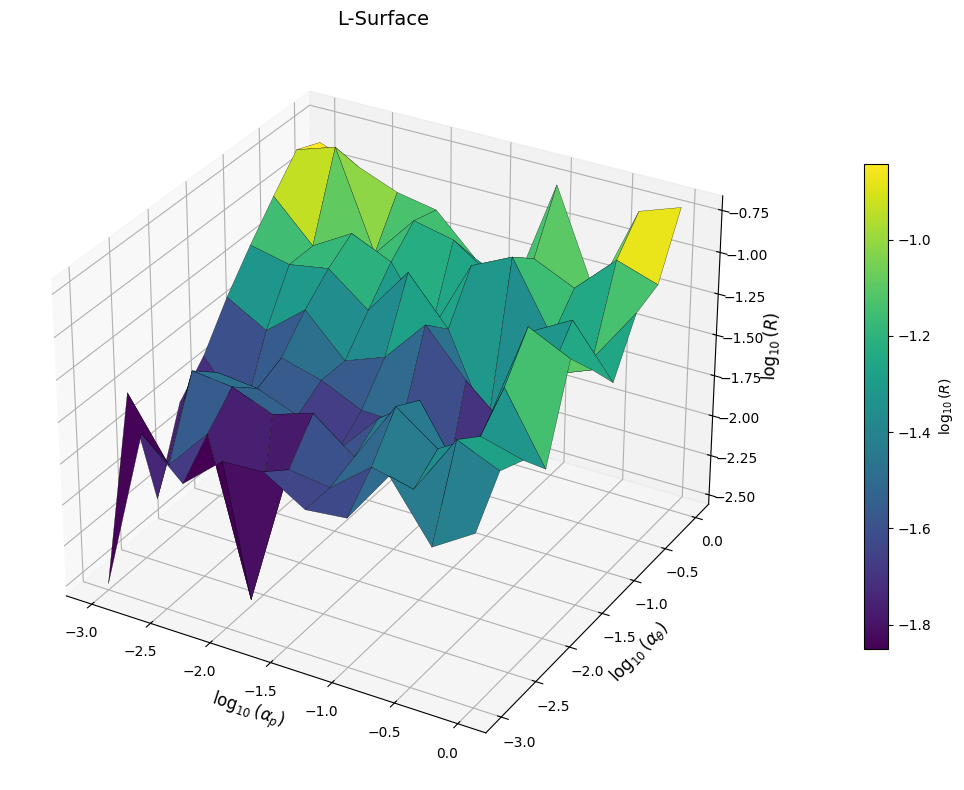

In [15]:
# %%
# ============================================================
# L-SURFACE PLOT
# ============================================================

fig = plt.figure(figsize=(11, 8))

ax = fig.add_subplot(111, projection="3d")

surface = ax.plot_surface(
    X,
    Y,
    Z,
    cmap="viridis",
    edgecolor="k",
    linewidth=0.2,
    antialiased=True
)

ax.set_xlabel(r"$\log_{10}(\alpha_p)$", fontsize=12)
ax.set_ylabel(r"$\log_{10}(\alpha_\theta)$", fontsize=12)
ax.set_zlabel(r"$\log_{10}(R)$", fontsize=12)

ax.set_title("L-Surface", fontsize=14)

fig.colorbar(
    surface,
    ax=ax,
    shrink=0.65,
    pad=0.1,
    label=r"$\log_{10}(R)$"
)

plt.tight_layout()
plt.show()

In [16]:
# %%

df = pd.DataFrame(results)

# ------------------------------------------------------------
# Log quantities
# ------------------------------------------------------------

epsilon = 1e-15

df["log_alpha_p"] = np.log10(df["alpha_p"] + epsilon)
df["log_alpha_theta"] = np.log10(df["alpha_theta"] + epsilon)

df["log_R"] = np.log10(df["misfit"] + epsilon)
df["log_R_p"] = np.log10(df["R_p"] + epsilon)
df["log_R_theta"] = np.log10(df["R_theta"] + epsilon)

df["log_J"] = np.log10(df["objective"] + epsilon)

In [17]:
# %%
# ------------------------------------------------------------
# Pareto frontier
# ------------------------------------------------------------

costs = df[
    [
        "misfit",
        "R_p",
        "R_theta",
    ]
].values

n_points = costs.shape[0]

is_pareto = np.ones(n_points, dtype=bool)

for i in range(n_points):

    if not is_pareto[i]:
        continue

    for j in range(n_points):

        if i == j:
            continue

        dominates = (
            np.all(costs[j] <= costs[i]) and
            np.any(costs[j] < costs[i])
        )

        if dominates:

            is_pareto[i] = False
            break

df["pareto"] = is_pareto

print(
    f"Pareto-optimal points: "
    f"{df['pareto'].sum()} / {len(df)}"
)

Pareto-optimal points: 17 / 100


In [18]:
# %%
# ------------------------------------------------------------
# Pareto subset
# ------------------------------------------------------------

pareto_df = (
    df[df["pareto"]]
    .copy()
    .reset_index(drop=False)
)

print(pareto_df[
    [
        "alpha_p",
        "alpha_theta",
        "misfit",
        "R_p",
        "R_theta",
        "objective",
    ]
])

     alpha_p  alpha_theta    misfit       R_p   R_theta  objective
0   0.001000     0.001000  0.003007  7.524681  6.771062   0.017302
1   0.001000     0.004642  0.005569  7.395904  5.803512   0.039903
2   0.010000     0.002154  0.003008  7.583905  5.748574   0.091232
3   0.046416     0.021544  0.020958  6.912708  5.756729   0.465843
4   0.100000     0.021544  0.007961  7.370558  5.446829   0.862365
5   0.100000     0.046416  0.033822  6.652366  5.674142   0.962429
6   0.100000     0.100000  0.013361  7.437253  4.356818   1.192768
7   0.215443     0.010000  0.018958  7.131002  5.390196   1.609188
8   0.215443     0.215443  0.041817  7.162526  4.360940   2.524472
9   0.215443     0.464159  0.062991  6.557884  4.094043   3.376130
10  0.215443     1.000000  0.044536  7.155586  4.406210   5.992371
11  0.464159     0.215443  0.036434  6.755644  4.475583   4.136362
12  1.000000     0.001000  0.030168  6.301827  5.861058   6.337856
13  1.000000     0.010000  0.029232  6.628990  6.400105   6.72

In [19]:
# %%
# ------------------------------------------------------------
# Stability metric in parameter space
# ------------------------------------------------------------

parameter_matrix = np.vstack(
    pareto_df["best_parameters"].values
)

stability = []

for i in range(len(pareto_df)):

    current = parameter_matrix[i]

    distances = np.linalg.norm(
        parameter_matrix - current,
        axis=1
    )

    distances[i] = np.inf

    nearest_distance = distances.min()

    stability.append(nearest_distance)

pareto_df["stability"] = stability

In [20]:
# %%
# ------------------------------------------------------------
# Normalize objectives
# ------------------------------------------------------------

for column in [
    "misfit",
    "R_p",
    "R_theta",
    "stability",
]:

    cmin = pareto_df[column].min()
    cmax = pareto_df[column].max()

    pareto_df[f"{column}_norm"] = (
        (pareto_df[column] - cmin) /
        (cmax - cmin + 1e-15)
    )

In [21]:
# %%
# ------------------------------------------------------------
# Composite robust score
# ------------------------------------------------------------

w_misfit = 0.50
w_reg_p = 0.20
w_reg_theta = 0.20
w_stability = 0.10

pareto_df["robust_score"] = (
    w_misfit * pareto_df["misfit_norm"] +
    w_reg_p * pareto_df["R_p_norm"] +
    w_reg_theta * pareto_df["R_theta_norm"] -
    w_stability * pareto_df["stability_norm"]
)

best_index = pareto_df["robust_score"].idxmin()

best_row = pareto_df.loc[best_index]

print(best_row[
    [
        "alpha_p",
        "alpha_theta",
        "misfit",
        "R_p",
        "R_theta",
        "objective",
        "stability",
        "robust_score",
    ]
])

alpha_p              0.1
alpha_theta          0.1
misfit          0.013361
R_p             7.437253
R_theta         4.356818
objective       1.192768
stability       2.575736
robust_score    0.220604
Name: 6, dtype: object


In [22]:
# %%
# ------------------------------------------------------------
# Recover optimal parameters
# ------------------------------------------------------------

optimal_parameters = best_row["best_parameters"]

print("\nOptimal recovered parameters:\n")

for i, value in enumerate(optimal_parameters):

    print(f"p[{i}] = {value:.6e}")


Optimal recovered parameters:

p[0] = 1.032564e-02
p[1] = 8.113651e-02
p[2] = 2.007158e-02
p[3] = 1.082343e+01
p[4] = 1.075630e+01
p[5] = 1.241236e+01
p[6] = 3.725020e-01
p[7] = 6.644816e-01
p[8] = 5.058932e-01
p[9] = 5.173847e-01
p[10] = 3.320059e+00
p[11] = 5.459102e-01
p[12] = 3.845616e-02
p[13] = 6.513144e-01
p[14] = 4.975062e-01
p[15] = 4.028712e-01


In [23]:
# %%
# ------------------------------------------------------------
# Neighbor analysis around optimum
# ------------------------------------------------------------

pareto_df["distance"] = np.sqrt(
    (
        pareto_df["log_alpha_p"] -
        best_row["log_alpha_p"]
    )**2
    +
    (
        pareto_df["log_alpha_theta"] -
        best_row["log_alpha_theta"]
    )**2
)

neighbors = (
    pareto_df
    .sort_values("distance")
    .head(7)
    .copy()
)

neighbors = neighbors.sort_values(
    by=[
        "log_alpha_p",
        "log_alpha_theta",
    ]
)

print(neighbors[
    [
        "log_alpha_p",
        "log_alpha_theta",
        "log_R",
        "log_R_p",
        "log_R_theta",
        "log_J",
        "stability",
        "robust_score",
    ]
])

    log_alpha_p  log_alpha_theta     log_R   log_R_p  log_R_theta     log_J  \
3     -1.333333        -1.666667 -1.678642  0.839648     0.760176 -0.331761   
4     -1.000000        -1.666667 -2.099031  0.867500     0.736144 -0.064309   
5     -1.000000        -1.333333 -1.470796  0.822976     0.753900 -0.016631   
6     -1.000000        -1.000000 -1.874163  0.871413     0.639169  0.076556   
8     -0.666667        -0.666667 -1.378651  0.855066     0.639580  0.402171   
9     -0.666667        -0.333333 -1.200724  0.816764     0.612152  0.528419   
11    -0.333333        -0.666667 -1.438489  0.829667     0.650850  0.616619   

    stability  robust_score  
3    3.402455      0.272686  
4    2.069932      0.280834  
5    2.025460      0.345321  
6    2.575736      0.220604  
8    2.087106      0.352693  
9    4.291261      0.298682  
11   1.455724      0.300823  


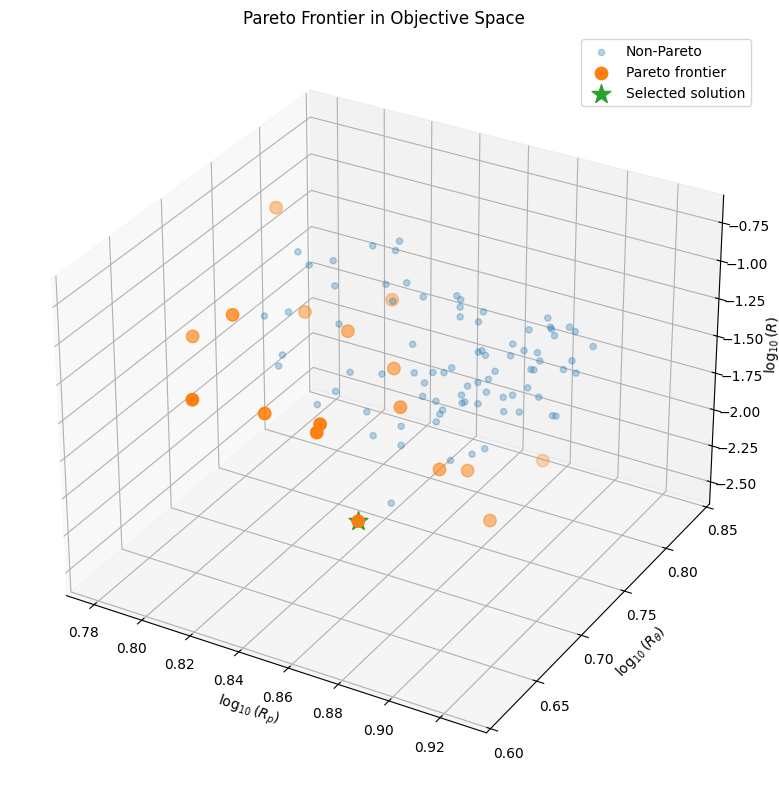

In [24]:
# %%
# ------------------------------------------------------------
# 3D Pareto visualization
# ------------------------------------------------------------

fig = plt.figure(figsize=(11, 8))

ax = fig.add_subplot(111, projection="3d")

non_pareto = df[~df["pareto"]]

ax.scatter(
    non_pareto["log_R_p"],
    non_pareto["log_R_theta"],
    non_pareto["log_R"],
    alpha=0.3,
    label="Non-Pareto"
)

ax.scatter(
    pareto_df["log_R_p"],
    pareto_df["log_R_theta"],
    pareto_df["log_R"],
    s=80,
    label="Pareto frontier"
)

ax.scatter(
    best_row["log_R_p"],
    best_row["log_R_theta"],
    best_row["log_R"],
    s=200,
    marker="*",
    label="Selected solution"
)

ax.set_xlabel(r"$\log_{10}(R_p)$")
ax.set_ylabel(r"$\log_{10}(R_\theta)$")
ax.set_zlabel(r"$\log_{10}(R)$")

ax.set_title(
    "Pareto Frontier in Objective Space"
)

ax.legend()

plt.tight_layout()
plt.show()

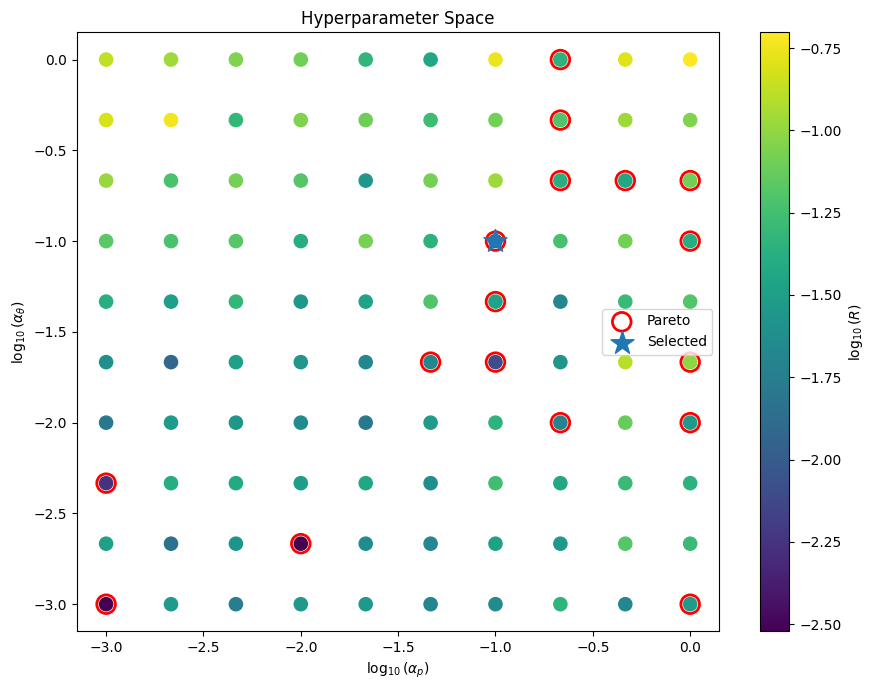

In [25]:
# %%
# ------------------------------------------------------------
# 2D hyperparameter map
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(9, 7)
)

scatter = ax.scatter(
    df["log_alpha_p"],
    df["log_alpha_theta"],
    c=df["log_R"],
    s=90,
    cmap="viridis",
)

ax.scatter(
    pareto_df["log_alpha_p"],
    pareto_df["log_alpha_theta"],
    s=180,
    facecolors="none",
    edgecolors="red",
    linewidths=2,
    label="Pareto"
)

ax.scatter(
    best_row["log_alpha_p"],
    best_row["log_alpha_theta"],
    s=300,
    marker="*",
    label="Selected"
)

ax.set_xlabel(
    r"$\log_{10}(\alpha_p)$"
)

ax.set_ylabel(
    r"$\log_{10}(\alpha_\theta)$"
)

ax.set_title(
    "Hyperparameter Space"
)

cbar = plt.colorbar(scatter)

cbar.set_label(
    r"$\log_{10}(R)$"
)

ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# %%
# ------------------------------------------------------------
# Generate LaTeX table
# ------------------------------------------------------------

columns = [
    "log_alpha_p",
    "log_alpha_theta",
    "log_R",
    "log_R_theta",
    "log_R_p",
    "log_J",
    "stability",
    "robust_score",
]

latex_rows = []

for idx, row in neighbors.iterrows():

    values = [
        f"{row[col]:.6f}"
        for col in columns
    ]

    line = " & ".join(values) + r" \\"

    if idx == best_index:

        values_bold = [
            rf"\textbf{{{row[col]:.6f}}}"
            for col in columns
        ]

        line = (
            " & ".join(values_bold)
            + r" \\"
        )

    latex_rows.append(line)

latex_table = rf"""
\begin{{table}}
\centering

\caption{{
Pareto-optimal solutions around the selected robust optimum.
The column ``Local Sensitivity'' corresponds to the minimum
Euclidean distance between neighboring Pareto-optimal parameter
vectors in the reconstruction space.
Smaller values indicate locally stable reconstructions under
perturbations of the regularization hyperparameters.
The highlighted row corresponds to the final selected
hyperparameter pair obtained through the composite robustness
criterion combining residual fit, regularization strength, and
local reconstruction sensitivity.
}}

\label{{tab:pareto_optimum}}

\resizebox{{\linewidth}}{{!}}{{
\begin{{tabular}}{{cccccccc}}
\hline

$\log \alpha_{{p}}$
&
$\log \alpha_{{\theta}}$
&
$\log R$
&
$\log R_{{\theta}}$
&
$\log R_{{p}}$
&
$\log J$
&
Sensitivity
&
Score
\\

\hline

{chr(10).join(latex_rows)}

\hline
\end{{tabular}}
}}

\end{{table}}
"""

print(latex_table)


\begin{table}
\centering

\caption{
Pareto-optimal solutions around the selected robust optimum.
The highlighted row corresponds to the final selected
hyperparameter pair based on the combined criterion involving
misfit, regularization, and local parameter stability.
}

\label{tab:pareto_optimum}

\resizebox{\linewidth}{!}{
\begin{tabular}{cccccccc}
\hline

$\log \alpha_{p}$
&
$\log \alpha_{\theta}$
&
$\log R$
&
$\log R_{\theta}$
&
$\log R_{p}$
&
$\log J$
&
Stability
&
Score
\\

\hline

-1.333333 & -1.666667 & -1.678642 & 0.760176 & 0.839648 & -0.331761 & 3.402455 & 0.272686 \\
-1.000000 & -1.666667 & -2.099031 & 0.736144 & 0.867500 & -0.064309 & 2.069932 & 0.280834 \\
-1.000000 & -1.333333 & -1.470796 & 0.753900 & 0.822976 & -0.016631 & 2.025460 & 0.345321 \\
\textbf{-1.000000} & \textbf{-1.000000} & \textbf{-1.874163} & \textbf{0.639169} & \textbf{0.871413} & \textbf{0.076556} & \textbf{2.575736} & \textbf{0.220604} \\
-0.666667 & -0.666667 & -1.378651 & 0.639580 & 0.855066 & 0.4021

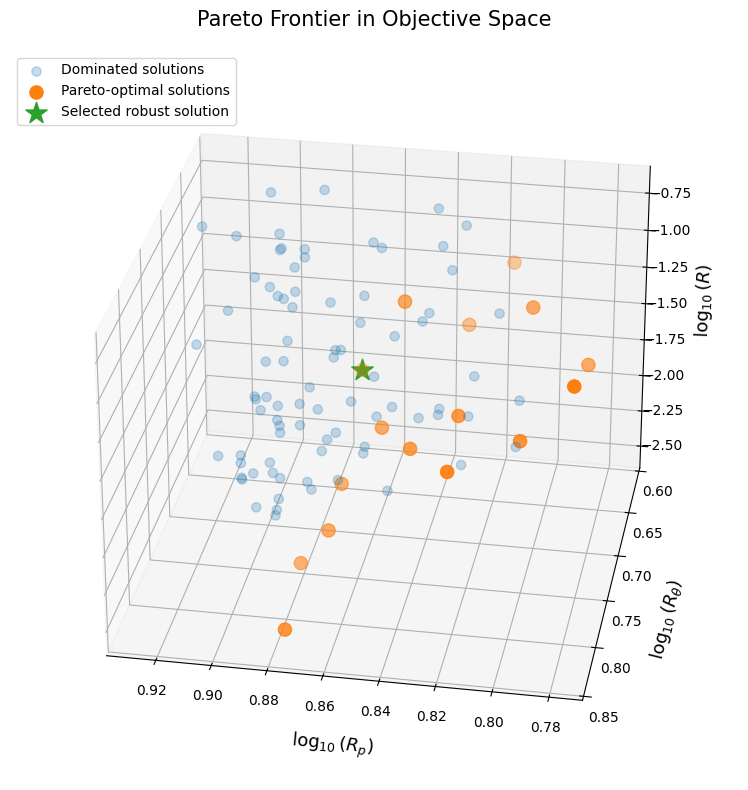

In [27]:
# %%
# ------------------------------------------------------------
# Pareto frontier in objective space
# ------------------------------------------------------------

fig = plt.figure(figsize=(20, 8))

ax = fig.add_subplot(111, projection="3d")

# ------------------------------------------------------------
# Non-Pareto solutions
# ------------------------------------------------------------

non_pareto = df[~df["pareto"]]

scatter_nonpareto = ax.scatter(
    non_pareto["log_R_p"],
    non_pareto["log_R_theta"],
    non_pareto["log_R"],
    s=45,
    alpha=0.25,
    label="Dominated solutions"
)

# ------------------------------------------------------------
# Pareto-optimal solutions
# ------------------------------------------------------------

scatter_pareto = ax.scatter(
    pareto_df["log_R_p"],
    pareto_df["log_R_theta"],
    pareto_df["log_R"],
    s=90,
    label="Pareto-optimal solutions"
)

# ------------------------------------------------------------
# Selected robust solution
# ------------------------------------------------------------

selected = best_row

ax.scatter(
    selected["log_R_p"],
    selected["log_R_theta"],
    selected["log_R"],
    s=260,
    marker="*",
    label="Selected robust solution"
)

# ------------------------------------------------------------
# Axis labels
# ------------------------------------------------------------

ax.set_xlabel(
    r"$\log_{10}(R_{p})$",
    fontsize=13,
    labelpad=12
)

ax.set_ylabel(
    r"$\log_{10}(R_{\theta})$",
    fontsize=13,
    labelpad=12
)

ax.set_zlabel(
    r"$\log_{10}(R)$",
    fontsize=13,
    labelpad=12
)

# ------------------------------------------------------------
# Title
# ------------------------------------------------------------

ax.set_title(
    "Pareto Frontier in Objective Space",
    fontsize=15,
    pad=18
)

# ------------------------------------------------------------
# View angle
# ------------------------------------------------------------

ax.view_init(
    elev=28,
    azim=100
)

# ------------------------------------------------------------
# Grid and legend
# ------------------------------------------------------------

ax.grid(True)

ax.legend(
    loc="upper left",
    fontsize=10
)

plt.tight_layout()

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

plt.savefig(
    "pareto_surface.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

```python
# ============================================================
# L-SURFACE COMPUTATION
# ============================================================

alpha_p_values = np.logspace(-3, 0, 10)
alpha_theta_values = np.logspace(-3, 0, 10)

results = []

for alpha_p in alpha_p_values:
    for alpha_theta in alpha_theta_values:

        print(
            f"Running optimization with "
            f"alpha_p={alpha_p:.2e}, "
            f"alpha_theta={alpha_theta:.2e}"
        )

        # ----------------------------------------------------
        # Optimization
        # ----------------------------------------------------

        best = ray.get(
            recovery.optimizer.remote(
                bounds=bounds,
                target_data=target_data,
                weight_p=alpha_p,
                weight_theta=alpha_theta,
                n_max=1
            )
        )

        # ----------------------------------------------------
        # Diagnostics
        # ----------------------------------------------------

        diagnostics = ray.get(
            recovery.objective_function.remote(
                np.array(best.x),
                target_data,
                weight_p=alpha_p,
                weight_theta=alpha_theta,
                return_components=True
            )
        )

        results.append({
            "alpha_p": alpha_p,
            "alpha_theta": alpha_theta,
            "objective": diagnostics["objective"],
            "misfit": diagnostics["misfit"],
            "R_p": diagnostics["R_p"],
            "R_theta": diagnostics["R_theta"],
            "best_parameters": np.array(best.x),
        })

# ============================================================
# DATAFRAME CONSTRUCTION
# ============================================================

df = pd.DataFrame(results)

epsilon = 1e-15

df["log_alpha_p"] = np.log10(df["alpha_p"] + epsilon)
df["log_alpha_theta"] = np.log10(df["alpha_theta"] + epsilon)

df["log_R"] = np.log10(df["misfit"] + epsilon)
df["log_R_p"] = np.log10(df["R_p"] + epsilon)
df["log_R_theta"] = np.log10(df["R_theta"] + epsilon)

df["log_J"] = np.log10(df["objective"] + epsilon)

# ============================================================
# PARETO FRONTIER
# ============================================================

costs = df[
    [
        "misfit",
        "R_p",
        "R_theta",
    ]
].values

n_points = costs.shape[0]

is_pareto = np.ones(n_points, dtype=bool)

for i in range(n_points):

    if not is_pareto[i]:
        continue

    for j in range(n_points):

        if i == j:
            continue

        dominates = (
            np.all(costs[j] <= costs[i]) and
            np.any(costs[j] < costs[i])
        )

        if dominates:

            is_pareto[i] = False
            break

df["pareto"] = is_pareto

# ============================================================
# PARETO SUBSET
# ============================================================

pareto_df = (
    df[df["pareto"]]
    .copy()
    .reset_index(drop=False)
)

# ============================================================
# LOCAL SENSITIVITY METRIC
# ============================================================

parameter_matrix = np.vstack(
    pareto_df["best_parameters"].values
)

sensitivity = []

for i in range(len(pareto_df)):

    current = parameter_matrix[i]

    distances = np.linalg.norm(
        parameter_matrix - current,
        axis=1
    )

    distances[i] = np.inf

    nearest_distance = distances.min()

    sensitivity.append(nearest_distance)

pareto_df["sensitivity"] = sensitivity

# ============================================================
# NORMALIZATION
# ============================================================

for column in [
    "misfit",
    "R_p",
    "R_theta",
    "sensitivity",
]:

    cmin = pareto_df[column].min()
    cmax = pareto_df[column].max()

    pareto_df[f"{column}_norm"] = (
        (pareto_df[column] - cmin) /
        (cmax - cmin + 1e-15)
    )

# ============================================================
# COMPOSITE ROBUSTNESS SCORE
# ============================================================

w_misfit = 0.50
w_reg_p = 0.20
w_reg_theta = 0.20
w_sensitivity = 0.10

pareto_df["robust_score"] = (
    w_misfit * pareto_df["misfit_norm"] +
    w_reg_p * pareto_df["R_p_norm"] +
    w_reg_theta * pareto_df["R_theta_norm"] +
    w_sensitivity * pareto_df["sensitivity_norm"]
)

best_index = pareto_df["robust_score"].idxmin()

best_row = pareto_df.loc[best_index]

# ============================================================
# NEIGHBOR ANALYSIS
# ============================================================

pareto_df["distance"] = np.sqrt(
    (
        pareto_df["log_alpha_p"] -
        best_row["log_alpha_p"]
    )**2
    +
    (
        pareto_df["log_alpha_theta"] -
        best_row["log_alpha_theta"]
    )**2
)

neighbors = (
    pareto_df
    .sort_values("distance")
    .head(7)
    .copy()
)

neighbors = neighbors.sort_values(
    by=[
        "log_alpha_p",
        "log_alpha_theta",
    ]
)

print(neighbors[
    [
        "log_alpha_p",
        "log_alpha_theta",
        "log_R",
        "log_R_p",
        "log_R_theta",
        "log_J",
        "sensitivity",
        "robust_score",
    ]
])
```